In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("nba2k-full.csv")
df.shape

(464, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464 entries, 0 to 463
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   full_name    464 non-null    object
 1   rating       464 non-null    int64 
 2   jersey       464 non-null    object
 3   team         441 non-null    object
 4   position     464 non-null    object
 5   b_day        464 non-null    object
 6   height       464 non-null    object
 7   weight       464 non-null    object
 8   salary       464 non-null    object
 9   country      464 non-null    object
 10  draft_year   464 non-null    int64 
 11  draft_round  464 non-null    object
 12  draft_peak   464 non-null    object
 13  college      388 non-null    object
 14  version      464 non-null    object
dtypes: int64(2), object(13)
memory usage: 54.5+ KB


In [5]:
print("\nValeurs manquantes par colonne :")
print(df.isna().sum())


Valeurs manquantes par colonne :
full_name       0
rating          0
jersey          0
team           23
position        0
b_day           0
height          0
weight          0
salary          0
country         0
draft_year      0
draft_round     0
draft_peak      0
college        76
version         0
dtype: int64


In [6]:
doublons = df[df.duplicated()]
print("\nLignes dupliquées :")
print(doublons)


Lignes dupliquées :
Empty DataFrame
Columns: [full_name, rating, jersey, team, position, b_day, height, weight, salary, country, draft_year, draft_round, draft_peak, college, version]
Index: []


In [7]:
df['draft_round'] = df['draft_round'].replace('Undrafted', 0).astype(int)
df['draft_peak'] = df['draft_peak'].replace('Undrafted', 0).astype(int)
df['salary'] = df['salary'].replace('[\$,]', '', regex=True).astype(float)

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/var/folders/t8/cvxqp8z14gndpvjgd_wg464w0000gn/T/ipykernel_89653/2051018018.py:3: SyntaxWarning: invalid escape sequence '\$'
  df['salary'] = df['salary'].replace('[\$,]', '', regex=True).astype(float)


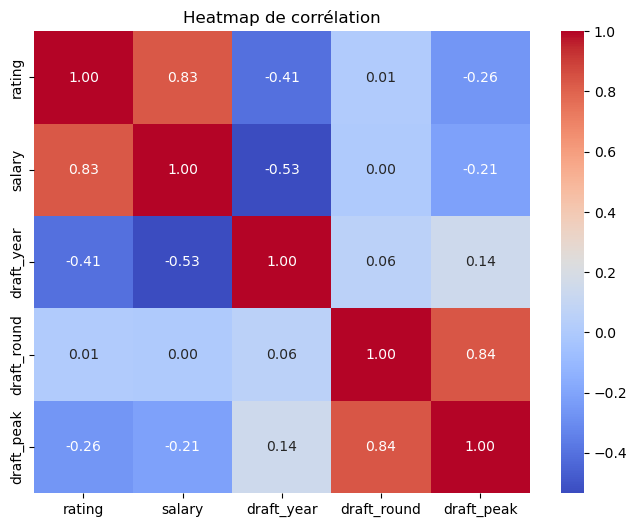

In [8]:
df_clean = df.select_dtypes(include=['int64', 'float64']) 
corr = df_clean.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap de corrélation")
plt.show()

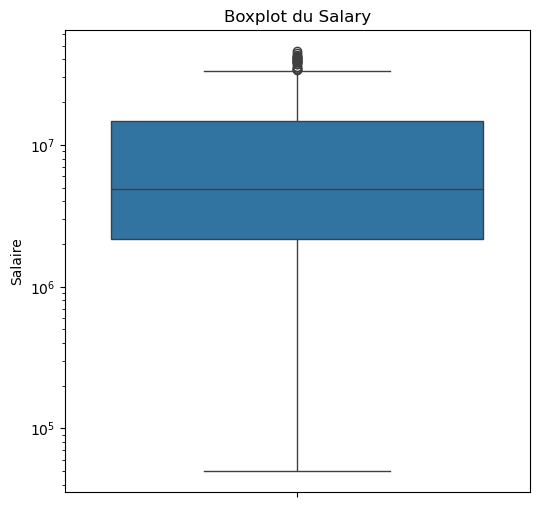

In [9]:
plt.figure(figsize=(6,6))
sns.boxplot(y=df_clean['salary'])
plt.title("Boxplot du Salary")
plt.ylabel("Salaire")
plt.yscale('log')
plt.show()

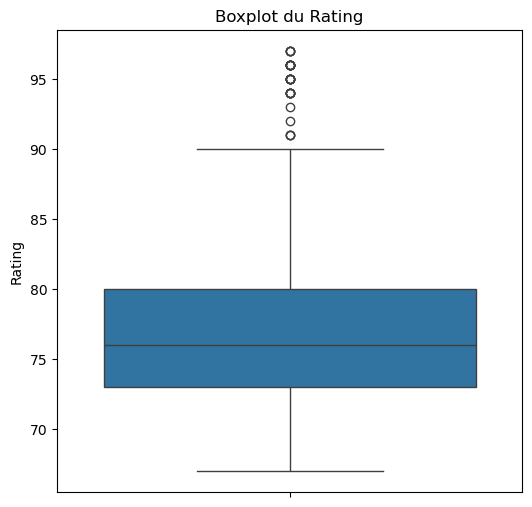

In [10]:
plt.figure(figsize=(6,6))
sns.boxplot(y=df_clean['rating'])
plt.title("Boxplot du Rating")
plt.ylabel("Rating")
plt.show()

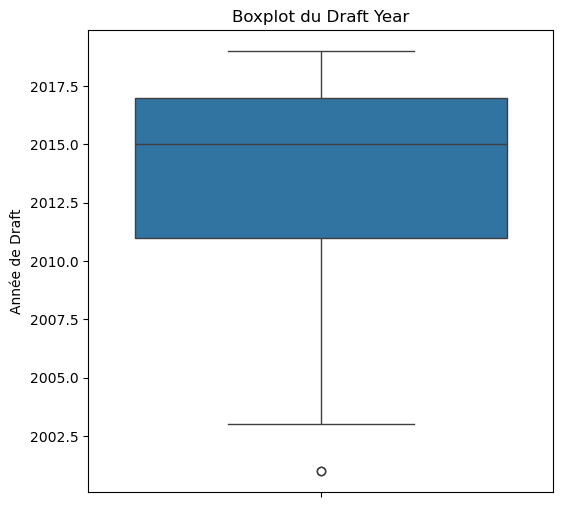

In [11]:
plt.figure(figsize=(6,6))
sns.boxplot(y=df_clean['draft_year'])
plt.title("Boxplot du Draft Year")
plt.ylabel("Année de Draft")
plt.show()

In [12]:
df['team'] = df['team'].fillna("No Team")

In [13]:
X = df[['rating', 'draft_year', 'draft_round', 'draft_peak', 'team']]
y = df['salary']

In [14]:
categorical_features = ['team']
numeric_features = ['rating', 'draft_year', 'draft_round', 'draft_peak']

In [15]:
preprocessor = ColumnTransformer([
    ("scaler", StandardScaler(), numeric_features),
    ("encoder", OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
linear_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", LinearRegression())
])
linear_model.fit(X_train, y_train)
y_pred_lin = linear_model.predict(X_test)

In [18]:
rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42
    ))
])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [19]:
def evaluate(model_name, y_true, y_pred):
    print(f"\n Performance : {model_name}")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²  :", r2_score(y_true, y_pred))
evaluate("Linear Regression", y_test, y_pred_lin)
evaluate("Random Forest", y_test, y_pred_rf)


 Performance : Linear Regression
MAE : 4473709.071916305
RMSE: 6004276.394900069
R²  : 0.7785904728790387

 Performance : Random Forest
MAE : 2960739.1707149255
RMSE: 4911504.439961968
R²  : 0.8518491885559933


In [20]:
def evaluate(model_name, y_true, y_pred):
    print(f"\n {model_name}")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²  :", r2_score(y_true, y_pred))

evaluate("Random Forest", y_test, y_pred_rf)
evaluate("XGBoost", y_test, y_pred_xgb)


 Random Forest
MAE : 2960739.1707149255
RMSE: 4911504.439961968
R²  : 0.8518491885559933


NameError: name 'y_pred_xgb' is not defined

In [21]:
ohe = rf_model.named_steps["preprocessing"].named_transformers_["encoder"]
encoded_teams = list(ohe.get_feature_names_out(['team']))
all_features = numeric_features + encoded_teams
importances = rf_model.named_steps["regressor"].feature_importances_
feature_imp = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)
print(feature_imp)

                        Feature  Importance
0                        rating    0.705750
1                    draft_year    0.167578
3                    draft_peak    0.048220
7        team_Charlotte Hornets    0.006765
13   team_Golden State Warriors    0.005925
30        team_Sacramento Kings    0.004590
21  team_Minnesota Timberwolves    0.004508
2                   draft_round    0.004448
5           team_Boston Celtics    0.003810
6            team_Brooklyn Nets    0.003644
9      team_Cleveland Cavaliers    0.003412
24                 team_No Team    0.003395
10        team_Dallas Mavericks    0.003296
8            team_Chicago Bulls    0.002994
12         team_Detroit Pistons    0.002851
20         team_Milwaukee Bucks    0.002768
25   team_Oklahoma City Thunder    0.002575
17      team_Los Angeles Lakers    0.002432
11          team_Denver Nuggets    0.002190
32         team_Toronto Raptors    0.002022
14         team_Houston Rockets    0.001707
4            team_Atlanta Hawks 

In [22]:
numeric_features = ['rating', 'draft_year', 'draft_round']
categorical_features = ['team']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [100, 200, 400],
    'regressor__max_depth': [5, 10, 20, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Meilleur RMSE :", -grid_search.best_score_)
print("Meilleurs paramètres :", grid_search.best_params_)

Fitting 3 folds for each of 324 candidates, totalling 972 fits
[CV] END regressor__max_depth=5, regressor__max_features=sqrt, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   0.2s
[CV] END regressor__max_depth=5, regressor__max_features=sqrt, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   0.1s
[CV] END regressor__max_depth=5, regressor__max_features=sqrt, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   0.1s
[CV] END regressor__max_depth=5, regressor__max_features=sqrt, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=200; total time=   0.2s
[CV] END regressor__max_depth=5, regressor__max_features=sqrt, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=200; total time=   0.2s
[CV] END regressor__max_depth=5, regressor__max_features=sqrt, regr

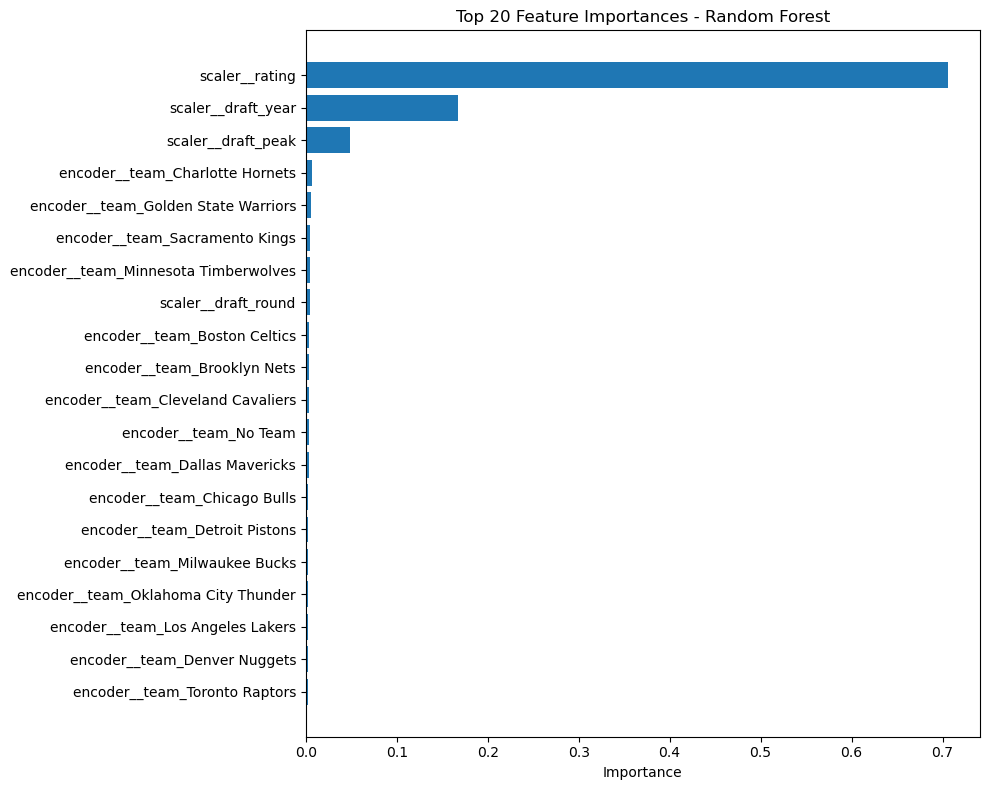

In [ ]:
preprocessor = rf_model.named_steps["preprocessing"]
rf = rf_model.named_steps["regressor"]
feature_names = preprocessor.get_feature_names_out()
importances = rf.feature_importances_
assert len(feature_names) == len(importances), "Mismatch entre features et importances"
feature_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10, 8))
plt.barh(
    feature_imp["Feature"].head(20),
    feature_imp["Importance"].head(20)
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

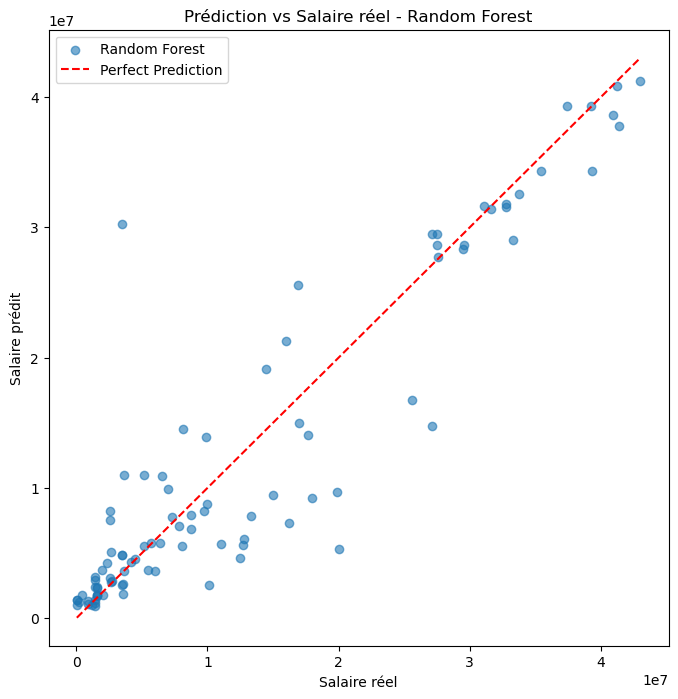

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred_rf, alpha=0.6, label="Random Forest")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction")
plt.xlabel("Salaire réel")
plt.ylabel("Salaire prédit")
plt.title("Prédiction vs Salaire réel - Random Forest")
plt.legend()
plt.show()

In [ ]:
def predict_salary():
    print("Entrez les informations du joueur pour prédire le salaire :")
    try:
        rating = float(input("Rating du joueur (ex: 85.5): "))
        draft_year = int(input("Année de draft (ex: 2022): "))
        draft_round = int(input("Tour de draft (1 ou 2): "))
        draft_peak = int(input("Pick de draft (ex: 5): "))
        team = input("Nom de l'équipe (ex: Lakers, No Team si inconnu): ")
    except:
        print("Erreur : vérifiez le format des valeurs saisies.")
        return
    player_df = pd.DataFrame({
        'rating': [rating],
        'draft_year': [draft_year],
        'draft_round': [draft_round],
        'draft_peak': [draft_peak],
        'team': [team]
    })
    salary_pred = rf_model.predict(player_df)[0]
    print(f"\n Salaire prédit du joueur : ${salary_pred:,.2f}")
predict_salary()

Entrez les informations du joueur pour prédire le salaire :

 Salaire prédit du joueur : $33,081,502.98
